# House Prices — Predição de Preços de Imóveis em Ames, Iowa

Pipeline completo de análise e modelagem para a competição *House Prices: Advanced
Regression Techniques* (Kaggle). O objetivo é prever o preço de venda (`SalePrice`)
de imóveis residenciais a partir de 79 variáveis explicativas.

**Métrica de avaliação:** RMSE entre o logaritmo do valor previsto e o logaritmo do
valor observado. A escolha do log implica que erros em imóveis caros e baratos pesam
igualmente — o que equivale a avaliar o erro *relativo*, não o absoluto. Essa
definição orienta várias decisões tomadas ao longo do notebook.

**Estrutura:**

1. Carga e primeira inspeção
2. Análise da variável alvo
3. Auditoria de dados faltantes
4. Tratamento e integração dos conjuntos
5. Feature engineering
6. Modelagem — baseline
7. Modelos de ensemble
8. Otimização de hiperparâmetros
9. Blend de modelos
10. Modelo final e artefatos
11. Comparação consolidada
12. Conclusões e limitações

## 1. Carga e primeira inspeção

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("data/train.csv")
print(train.shape)
train.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


O conjunto de treino tem **1460 observações e 81 colunas** (79 features, o
identificador `Id` e o alvo `SalePrice`).

A razão entre número de amostras e número de variáveis é o primeiro fator de risco do
problema: 1460 linhas é pouco, e a expansão one-hot das variáveis categóricas tende a
multiplicar o número de colunas. Poucas amostras e muitas dimensões favorecem o
**overfitting** — motivo pelo qual o baseline adotado é um modelo linear regularizado
e pelo qual toda avaliação é feita por validação cruzada, nunca sobre o erro de treino.

## 2. Análise da variável alvo

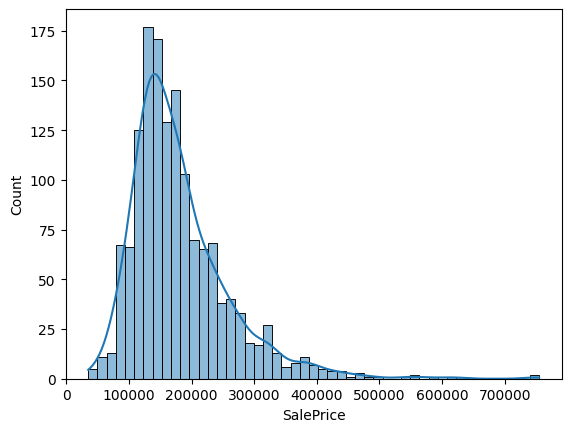

In [2]:
sns.histplot(train["SalePrice"], kde=True)
plt.show()

A distribuição de `SalePrice` é **assimétrica à direita**: concentração de imóveis em
faixas de preço intermediárias e uma cauda longa formada por poucos imóveis de alto
padrão.

### Decisão: aplicar transformação logarítmica ao alvo

Três justificativas convergentes:

1. **Alinhamento com a métrica.** A competição avalia o RMSE no logaritmo do preço.
   Treinar o modelo diretamente sobre `log(SalePrice)` faz com que a função otimizada
   no treino seja a mesma usada na avaliação. Treinar no preço bruto e ser avaliado no
   log significaria otimizar um objetivo diferente do cobrado.

2. **Correção da assimetria.** O log comprime a cauda superior e aproxima a
   distribuição de uma normal. Modelos lineares assumem resíduos aproximadamente
   simétricos; uma cauda longa viola essa premissa e concentra o erro nos imóveis caros.

3. **Erro relativo em vez de absoluto.** No espaço logarítmico, o que é penalizado é a
   diferença percentual. Errar R$ 10 mil num imóvel de R$ 100 mil passa a pesar mais do
   que o mesmo erro num imóvel de R$ 500 mil — exatamente o comportamento descrito no
   enunciado da competição.

Utilizamos `np.log1p` (log(1+x)) por estabilidade numérica; para valores na ordem de
10⁵ a diferença em relação ao log natural é desprezível. **Consequência:** o modelo
passa a prever em escala logarítmica, e a previsão final precisa ser revertida com
`np.expm1` antes de ser interpretada em dólares.

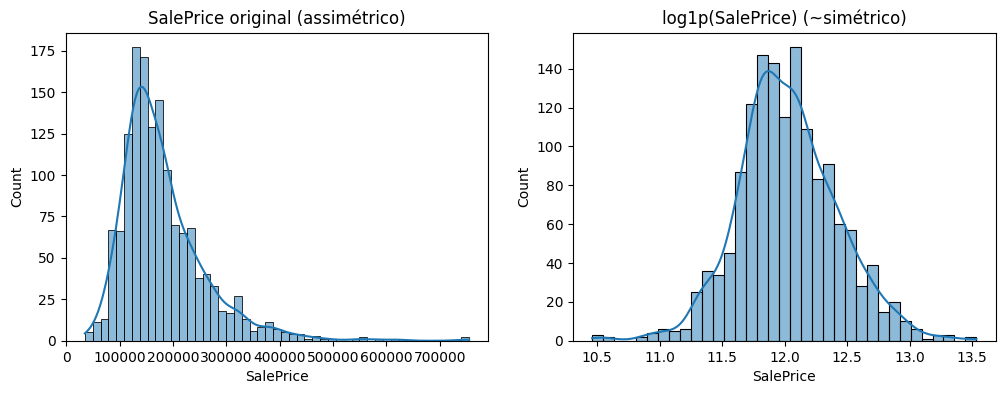

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice original (assimétrico)")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice) (~simétrico)")
plt.show()

A comparação confirma o efeito: a distribuição transformada é aproximadamente
simétrica, adequada ao uso em modelos lineares.

## 3. Auditoria de dados faltantes

Antes de qualquer imputação, é necessário quantificar os valores ausentes e — mais
importante — investigar o que cada `NaN` significa no dicionário de dados
(`data_description.txt`).

In [4]:
missing = pd.DataFrame({
    "n_missing": train.isna().sum(),
    "pct": (train.isna().mean() * 100).round(2)
})
missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)

,n_missing,pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### Achado central: os `NaN` majoritários não são dados perdidos

As cinco colunas com maior incidência de ausência revelam um padrão:

| Coluna | % ausente | Significado do `NaN` |
|---|---|---|
| `PoolQC` | 99,52% | Imóvel sem piscina |
| `MiscFeature` | 96,30% | Sem características adicionais (ex.: quadra de tênis) |
| `Alley` | 93,76% | Sem acesso por viela |
| `Fence` | 80,75% | Sem cerca |
| `MasVnrType` | 59,72% | Sem revestimento de alvenaria |

Em todos os casos, o `NaN` **codifica a ausência da característica**, não a falha no
registro. Trata-se de *missingness informativo*. A distinção é decisiva: imputar a moda
em `PoolQC` equivaleria a atribuir uma piscina a imóveis que não possuem nenhuma,
introduzindo informação falsa.

O tratamento correto separa dois casos:

- **Ausência** → preencher com categoria explícita (`"None"`) ou com `0` nas colunas
  numéricas correspondentes (área, contagem). A ausência passa a ser um valor válido,
  não um buraco.
- **Ausência real** → imputar. O exemplo típico é `LotFrontage` (metros de rua na
  frente do lote): todo imóvel possui alguma testada, logo um `NaN` indica falta de
  registro, e não inexistência.

## 4. Tratamento e integração dos conjuntos

O tratamento é encapsulado em uma função aplicada **aos dois conjuntos**. Essa é a
etapa de integração dos dados: `train` e `test` precisam passar por exatamente o mesmo
pré-processamento. O conjunto de teste apresenta valores ausentes em colunas que o
treino não possui — limpar apenas o treino produziria incompatibilidade na etapa de
predição.

Duas decisões merecem registro:

- **`LotFrontage` imputado pela mediana do bairro**, e não pela mediana global. Imóveis
  de um mesmo bairro tendem a ter testadas semelhantes, o que torna a imputação mais
  fiel à realidade local.
- **`GarageYrBlt` preenchido com `0`** quando não há garagem. A escolha cria um "ano
  zero" artificial; uma alternativa seria usar o `YearBuilt` do imóvel. Optamos pelo
  zero por consistência com as demais colunas de ausência.

In [5]:
none_cols = ["PoolQC","MiscFeature","Alley","Fence","FireplaceQu","MasVnrType",
             "GarageType","GarageFinish","GarageQual","GarageCond",
             "BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"]

zero_cols = ["MasVnrArea","GarageYrBlt","GarageCars","GarageArea",
             "BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","TotalBsmtSF",
             "BsmtFullBath","BsmtHalfBath"]

mode_cols = ["Electrical","MSZoning","KitchenQual","SaleType",
             "Exterior1st","Exterior2nd","Functional","Utilities"]

def clean(df):
    df = df.copy()
    for c in none_cols:                      # ausência informativa (categórica)
        df[c] = df[c].fillna("None")
    for c in zero_cols:                       # ausência informativa (numérica)
        df[c] = df[c].fillna(0)
    for c in mode_cols:                       # ausência real (categórica)
        df[c] = df[c].fillna(df[c].mode()[0])
    # LotFrontage: mediana por bairro (imóveis vizinhos têm testada similar,
    # o que torna a imputação mais fiel que a mediana global)
    df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median()))
    return df

test = pd.read_csv("data/test.csv")
train = clean(train)
test  = clean(test)

# verificação: deve retornar 0 em ambos
print(train.isna().sum().sum(), test.isna().sum().sum())

0 0


A verificação retorna `0 0`: nenhum valor ausente remanescente em treino ou teste.

## 5. Feature engineering

### 5.1 Encoding: variáveis ordinais vs. nominais

As variáveis categóricas do dataset se dividem em duas naturezas distintas, e tratá-las
de forma indiferenciada descarta informação:

- **Ordinais** — as colunas de qualidade seguem uma escala explícita
  (`Po < Fa < TA < Gd < Ex`). Aplicar one-hot nelas destruiria essa ordem: o modelo
  passaria a tratar "Excelente" e "Péssimo" como categorias sem relação entre si. O
  tratamento adequado é o mapeamento para valores numéricos que preservem a ordenação.
- **Nominais** — `Neighborhood`, `MSZoning` e similares não possuem ordem intrínseca.
  Atribuir números a elas criaria uma hierarquia inexistente. Essas seguem para one-hot.

Note que o valor `"None"` criado na etapa de tratamento é mapeado para `0`, posição
inferior a "Péssimo" na escala. A codificação é coerente com o domínio: não possuir
garagem representa condição inferior a possuir uma garagem em mau estado.

In [6]:
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
qual_cols = ["ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC",
             "KitchenQual","FireplaceQu","GarageQual","GarageCond","PoolQC"]

for df in (train, test):
    for c in qual_cols:
        df[c] = df[c].map(qual_map)

### 5.2 Criação de variáveis derivadas

Feature engineering aqui não introduz informação nova — reorganiza a informação
existente em variáveis mais alinhadas com a lógica de formação do preço:

| Feature | Construção | Justificativa |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | A área habitável total é o que o comprador percebe; dispersa em três colunas, o sinal fica diluído |
| `HouseAge` | `YrSold - YearBuilt` | O que afeta o preço é a idade do imóvel na data da venda, não o ano-calendário de construção |
| `TotalBath` | Banheiros completos + 0,5 × lavabos (casa e porão) | Consolida em um único indicador informação espalhada por quatro colunas |

**Ordem de execução:** estas variáveis são criadas **antes** da transformação
logarítmica das features (seção 5.3). Somas precisam ser feitas sobre os valores reais
das áreas — somar valores já logaritmizados não corresponde ao log da soma
(`log a + log b ≠ log(a+b)`) e produziria uma variável sem significado físico. Se as
features derivadas apresentarem assimetria, elas serão captadas naturalmente pela etapa
seguinte.

In [7]:
for df in (train, test):
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["TotalBath"] = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]

### 5.3 Correção de assimetria nas variáveis numéricas

O mesmo diagnóstico aplicado ao alvo vale para as features: áreas e dimensões de lote
apresentam cauda longa à direita, o que prejudica modelos lineares. Detectamos as
variáveis com assimetria acima de 0,75 em módulo (limiar usual) e aplicamos `log1p`.

Vale registrar que essa transformação, assim como a padronização, é **monotônica**:
beneficia modelos lineares e é indiferente para modelos baseados em árvore, que operam
apenas sobre a ordenação dos valores. A preparação, portanto, favorece explicitamente a
família linear sem prejudicar as demais.

In [8]:
from scipy.stats import skew

num_cols = train.select_dtypes(include=[np.number]).columns
num_cols = num_cols.drop(["Id","SalePrice"])   # exclui identificador e alvo

skewed = train[num_cols].apply(lambda x: skew(x.dropna()))
skewed = skewed[abs(skewed) > 0.75].index      # limiar usual na literatura

for df in (train, test):
    for c in skewed:
        df[c] = np.log1p(df[c])

### 5.4 One-hot encoding e alinhamento entre conjuntos

As variáveis nominais restantes são convertidas em dummies. O ponto crítico é que
`train` e `test` podem conter categorias distintas, gerando conjuntos de colunas
diferentes após o encoding — o que inviabilizaria a predição. O método `align` força a
mesma estrutura de colunas em ambos, preenchendo com `0` as categorias ausentes.

In [9]:
y = np.log1p(train["SalePrice"])          # alvo em escala logarítmica
train_ids = train["Id"]; test_ids = test["Id"]

X = train.drop(columns=["Id","SalePrice"])
X_test = test.drop(columns=["Id"])

X = pd.get_dummies(X)
X_test = pd.get_dummies(X_test)
X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)  # garante estrutura de colunas idêntica

print(X.shape, X_test.shape)   # o número de colunas deve ser idêntico

(1460, 265) (1459, 265)


Resultado: `X` com 1460 × 265 e `X_test` com 1459 × 265. O número de colunas é
idêntico nos dois conjuntos, e as 79 features originais expandiram para 265 após o
one-hot — confirmando a preocupação com dimensionalidade levantada na seção 1.

## 6. Modelagem — baseline

### Protocolo de validação

O erro medido sobre o próprio conjunto de treino avalia a capacidade de memorização, não
a de generalização — e com 265 features para 1460 observações, a memorização é
trivialmente alcançável. Toda avaliação é portanto feita por **validação cruzada
5-fold**: o conjunto é dividido em cinco partes, o modelo é treinado em quatro e
avaliado na restante, repetindo-se o procedimento cinco vezes.

Como o alvo `y` já está em escala logarítmica, o RMSE obtido na validação cruzada mede
diretamente a métrica da competição, sem necessidade de conversão. O mesmo objeto
`KFold` (`random_state=42`) é reutilizado em todos os modelos, garantindo que as
comparações sejam feitas sobre partições idênticas.

### Padronização e vazamento de dados

Ridge e Lasso penalizam a magnitude dos coeficientes. Quando as features estão em
escalas distintas (`TotalSF` na ordem dos milhares, `OverallQual` de 1 a 10), a
penalização incide de forma desigual — não em função da relevância da variável, mas da
sua unidade de medida. A padronização é, portanto, obrigatória para essa família.

Ela precisa ocorrer **dentro** de cada fold. Padronizar `X` integralmente antes da
validação faria com que média e desvio calculados incluíssem as observações de
validação, caracterizando *data leakage* e produzindo estimativa otimista. O uso de
`Pipeline` resolve o problema: o scaler é reajustado a cada fold. Optamos por
`RobustScaler` (mediana e IQR) por sua menor sensibilidade aos outliers presentes no
dataset.

In [10]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model):
    scores = cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=kf)
    return -scores.mean(), scores.std()

ridge = make_pipeline(RobustScaler(), Ridge(alpha=10))
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.001, max_iter=10000))

for nome, modelo in [("Ridge", ridge), ("Lasso", lasso)]:
    media, desvio = rmse_cv(modelo)
    print(f"{nome}: RMSE = {media:.4f} (+/- {desvio:.4f})")

Ridge: RMSE = 0.1300 (+/- 0.0205)
Lasso: RMSE = 0.1297 (+/- 0.0209)


**Leitura dos resultados.** Ridge (0,1300) e Lasso (0,1297) diferem em 0,0003, enquanto
o desvio-padrão entre folds é da ordem de 0,02 — cerca de setenta vezes maior que a
diferença observada. Trata-se de **empate estatístico**: declarar um vencedor aqui seria
interpretar ruído como sinal.

O desvio de 0,02 (aproximadamente 15% da média) também é informativo: indica que o
desempenho varia de forma relevante entre partições. A hipótese mais provável são os
outliers conhecidos do dataset — imóveis com `GrLivArea > 4000` vendidos a preços muito
abaixo do esperado, associados a vendas atípicas —, que degradam o fold em que caem.

## 7. Modelos de ensemble

Modelos baseados em árvore não requerem padronização. Uma árvore de decisão não realiza
operações aritméticas sobre os valores das features: ela busca **pontos de corte**
(`TotalSF <= 2000`?) e utiliza apenas a ordenação das observações. Como a padronização é
uma transformação monotônica, ela não altera a ordem — os mesmos cortes seriam
encontrados, apenas expressos em outra escala. Os modelos são portanto aplicados
diretamente sobre `X`.

In [11]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

rf  = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
gbr = GradientBoostingRegressor(n_estimators=300, random_state=42)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1)

for nome, modelo in [("RandomForest", rf), ("GradientBoosting", gbr), ("XGBoost", xgb)]:
    media, desvio = rmse_cv(modelo)
    print(f"{nome}: RMSE = {media:.4f} (+/- {desvio:.4f})")

RandomForest: RMSE = 0.1418 (+/- 0.0186)
GradientBoosting: RMSE = 0.1327 (+/- 0.0179)
XGBoost: RMSE = 0.1374 (+/- 0.0179)


**Leitura dos resultados.** O resultado é contraintuitivo: os modelos lineares
regularizados superam os ensembles em configuração padrão. Quatro fatores explicam o
comportamento:

1. **Volume de dados.** 1460 observações é pouco para que modelos baseados em árvore
   identifiquem interações complexas de forma confiável; com poucos dados, tendem a
   ajustar ruído.
2. **Natureza da relação.** A associação entre as principais features e o preço é
   predominantemente linear (área maior → preço proporcionalmente maior), justamente o
   que Ridge e Lasso modelam de forma nativa.
3. **Preparação orientada ao modelo linear.** As transformações aplicadas (log no alvo e
   nas features assimétricas, encoding ordinal) linearizaram as relações, beneficiando a
   família linear e sendo indiferentes para as árvores.
4. **Alta dimensionalidade esparsa.** As 265 colunas incluem grande número de dummies
   majoritariamente nulas. O RandomForest sorteia subconjuntos de features a cada corte e
   frequentemente avalia variáveis pouco informativas — o que ajuda a explicar seu pior
   desempenho (0,1418).

Cabe ressaltar que a comparação ainda é desfavorável aos ensembles: eles operam em
configuração padrão, enquanto Ridge e Lasso possuem poucos hiperparâmetros relevantes.
Essa assimetria motiva a etapa seguinte.

## 8. Otimização de hiperparâmetros

### 8.1 Busca exaustiva (GridSearchCV)

Os três hiperparâmetros mais influentes do XGBoost:

- **`n_estimators`** — número de árvores. Mais árvores aumentam a capacidade, com
  retorno decrescente.
- **`learning_rate`** — peso da correção aportada por cada nova árvore. Valores baixos
  produzem aprendizado gradual e melhor generalização, mas exigem mais árvores para
  convergir. Os dois parâmetros são, portanto, **acoplados**.
- **`max_depth`** — profundidade das árvores. Árvores profundas capturam interações
  complexas e superajustam rapidamente em conjuntos pequenos.

Dado o tamanho do dataset, a hipótese de trabalho é que o ótimo esteja na região de
árvores rasas e taxa de aprendizado baixa — ambos atuando como freios ao overfitting por
mecanismos distintos: `max_depth` limita o quanto cada árvore pode memorizar,
`learning_rate` limita a influência de cada árvore no resultado agregado.

A busca reutiliza o mesmo `KFold` das etapas anteriores, mantendo a comparabilidade.

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [500, 1000],
    "learning_rate": [0.01, 0.05],
    "max_depth": [3, 4, 5],
}

grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kf,              # mesma partição usada nas demais avaliações
    verbose=1,
)
grid.fit(X, y)

print("Melhores parâmetros:", grid.best_params_)
print(f"Melhor RMSE: {-grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000}
Melhor RMSE: 0.1301


**Leitura dos resultados.** O tuning reduziu o RMSE de 0,1374 para 0,1301 sem qualquer
alteração nos dados, e `max_depth=3` confirma a hipótese de árvores rasas.

Duas observações relevantes:

- **Os três parâmetros selecionados caíram nas bordas do grid** (`max_depth` no menor
  valor testado, `n_estimators` e `learning_rate` nos maiores). Isso indica que o ótimo
  pode estar fora do espaço explorado — a busca "pediu" valores que não foram oferecidos.
- **`learning_rate=0.01` perdeu para 0.05**, aparentemente contrariando a hipótese
  inicial. A explicação está no acoplamento: com apenas 1000 árvores, a taxa de 0,01 não
  dispõe de iterações suficientes para convergir. O que se observa é *underfitting*, não
  falha da premissa. A regra correta é que taxas baixas generalizam melhor **desde que
  acompanhadas de número suficiente de árvores**.

### 8.2 Busca aleatória (RandomizedSearchCV)

Estender o grid nas direções indicadas tornaria a busca exaustiva proibitiva — o número
de combinações cresce multiplicativamente. `RandomizedSearchCV` amostra um número fixo
de combinações de um espaço amplo, cobrindo mais território por treino realizado.

O espaço de busca estende as bordas identificadas (profundidade a partir de 2, até 3000
árvores, taxas de 0,01 a 0,05) e incorpora dois regularizadores adicionais adequados a
conjuntos pequenos: `subsample` (fração de linhas por árvore) e `colsample_bytree`
(fração de colunas por árvore), ambos introduzindo aleatoriedade que dificulta a
memorização.

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [1000, 2000, 3000],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.4, 0.6, 0.8],
    "min_child_weight": [1, 3, 5],
}

rs = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=30,              # 30 combinações amostradas do espaço de busca
    scoring="neg_root_mean_squared_error",
    cv=kf,
    random_state=42,
    verbose=1,
)
rs.fit(X, y)

print("Melhores:", rs.best_params_)
print(f"RMSE: {-rs.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores: {'subsample': 0.6, 'n_estimators': 2000, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.4}
RMSE: 0.1231


**Leitura dos resultados.** RMSE de **0,1231** — melhor resultado do projeto, e redução
consistente frente ao GridSearch (0,1301) e ao XGBoost padrão (0,1374).

A configuração vencedora é coerente com o diagnóstico: `learning_rate=0.01` prevalece
agora que dispõe de 2000 árvores, confirmando a interpretação do acoplamento na seção
8.1. `subsample=0.6` e `colsample_bytree=0.4` indicam regularização agressiva — cada
árvore observa 60% das linhas e apenas 40% das colunas. O valor baixo de
`colsample_bytree` é consistente com a esparsidade da matriz: restringir o conjunto de
colunas candidatas aumenta a probabilidade de que features informativas sejam avaliadas
sem competição das dummies.

**Limitação:** vários parâmetros novamente se aproximaram das bordas inferiores do
espaço, sugerindo que ainda há margem de exploração não coberta.

## 9. Blend de modelos

Lasso e XGBoost erram de formas distintas: o modelo linear captura bem a tendência
global, mas não representa interações; o boosting captura não-linearidades e interações,
mas extrapola mal. Quando os erros de dois modelos são pouco correlacionados, a média
ponderada das previsões tende a errar menos que qualquer um isoladamente — os desvios
se compensam parcialmente. Combinar famílias distintas costuma render mais do que
combinar modelos semelhantes.

A avaliação usa `cross_val_predict`, que gera para cada observação a previsão do fold em
que ela era validação, garantindo previsões sempre *out-of-sample*.

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

xgb_best = rs.best_estimator_

lasso_oof = cross_val_predict(lasso, X, y, cv=kf)
xgb_oof   = cross_val_predict(xgb_best, X, y, cv=kf)

for w in [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1]:
    blend = w*lasso_oof + (1-w)*xgb_oof
    rmse = np.sqrt(mean_squared_error(y, blend))
    print(f"peso Lasso={w:.1f} | XGB={1-w:.1f} -> RMSE = {rmse:.4f}")

peso Lasso=0.0 | XGB=1.0 -> RMSE = 0.1243
peso Lasso=0.2 | XGB=0.8 -> RMSE = 0.1234
peso Lasso=0.3 | XGB=0.7 -> RMSE = 0.1234
peso Lasso=0.4 | XGB=0.6 -> RMSE = 0.1237
peso Lasso=0.5 | XGB=0.5 -> RMSE = 0.1243
peso Lasso=0.6 | XGB=0.4 -> RMSE = 0.1251
peso Lasso=0.8 | XGB=0.2 -> RMSE = 0.1277
peso Lasso=1.0 | XGB=0.0 -> RMSE = 0.1314


**Leitura dos resultados.** A curva apresenta formato de U assimétrico. O melhor blend
(w ≈ 0,2–0,3) atinge 0,1234 contra 0,1243 do XGBoost isolado — diferença de 0,0009,
inferior ao desvio da validação cruzada e portanto **não conclusiva**. O que a tabela
demonstra com clareza é a assimetria: o erro cresce rapidamente na direção do Lasso puro
(0,1314) e permanece praticamente estável na direção do XGBoost. O XGBoost domina, e a
contribuição do Lasso é marginal.

Adotamos **w = 0,25** por dois motivos: o ganho, ainda que pequeno, é consistente; e a
combinação de famílias distintas tende a apresentar comportamento mais robusto em dados
não vistos do que o indicado pela validação local.

**Duas ressalvas metodológicas:**

- O peso `w` foi escolhido observando o resultado da própria validação cruzada, o que
  introduz um viés otimista na estimativa. Com um único parâmetro e uma grade grosseira o
  efeito é pequeno, mas o número reportado para o blend não é inteiramente independente.
- O Lasso registra 0,1314 nesta tabela contra 0,1297 na seção 6. A diferença é
  metodológica, não um erro: `cross_val_score` calcula o RMSE por fold e retorna a média,
  enquanto `cross_val_predict` agrega todas as previsões out-of-fold e calcula um único
  RMSE. Como o RMSE não é linear, os valores divergem.

## 10. Modelo final e artefatos

O modelo final é treinado sobre as 1460 observações completas — a validação cruzada já
cumpriu seu papel de estimar o erro de generalização, e o treino final aproveita todos os
dados disponíveis.

A previsão é gerada em escala logarítmica e revertida com `np.expm1`, conforme
antecipado na seção 2.

In [15]:
W = 0.25  # peso do Lasso, definido na seção 9

# treino sobre o conjunto completo: a CV já estimou o erro de generalização
lasso.fit(X, y)
xgb_best.fit(X, y)

pred_log = W * lasso.predict(X_test) + (1 - W) * xgb_best.predict(X_test)
pred = np.expm1(pred_log)          # reverte log1p -> escala original (dólares)

sub = pd.DataFrame({"Id": test_ids, "SalePrice": pred})
sub.to_csv("submission.csv", index=False)

print(sub.head())
print(sub["SalePrice"].describe())

     Id      SalePrice
0  1461  121072.938525
1  1462  158821.646949
2  1463  185334.997389
3  1464  193043.087515
4  1465  191686.872939
count      1459.000000
mean     177538.427019
std       74524.632554
min       42349.280494
25%      127603.292473
50%      156312.839459
75%      210244.762408
max      513731.298847
Name: SalePrice, dtype: float64


As estatísticas das previsões são consistentes com o domínio: média de aproximadamente
US$ 177 mil, mínimo de US$ 42 mil e máximo de US$ 514 mil, sem valores negativos ou fora
de escala — confirmando que a reversão logarítmica foi aplicada corretamente.

Nota-se que o máximo previsto é inferior ao máximo observado no treino. Trata-se de
**regressão à média**: modelos de regressão tendem a comprimir os extremos, já que
previsões próximas à média minimizam o erro quadrático. Na prática, o modelo subestima
sistematicamente imóveis de alto padrão.

### Persistência do modelo

O artefato serializado alimenta o simulador em Streamlit (`app.py`). Além dos modelos
treinados, é necessário armazenar a estrutura exata usada no treino: a ordem das colunas,
a lista de features que receberam `log1p` e a linha mediana de referência. Sem esses
metadados, o aplicativo não teria como reproduzir o mesmo pré-processamento, e qualquer
divergência produziria previsões incorretas de forma silenciosa.

In [16]:
import joblib

artefato = {
    "lasso": lasso,
    "xgb": xgb_best,
    "w": W,
    "cols": list(X.columns),                 # ordem exata das colunas
    "median_row": X.astype(float).median(),  # imóvel de referência para o simulador
    "skewed": list(skewed),                  # features transformadas com log1p
}
joblib.dump(artefato, "modelo.joblib")
print("ok:", len(artefato["cols"]), "colunas")

ok: 265 colunas


## 11. Comparação consolidada dos modelos

In [17]:
resultados = pd.DataFrame([
    ("Lasso",                       0.1297, 0.0209, "Linear regularizado"),
    ("Ridge",                       0.1300, 0.0205, "Linear regularizado"),
    ("RandomForest",                0.1418, 0.0186, "Ensemble (bagging)"),
    ("GradientBoosting",            0.1327, 0.0179, "Ensemble (boosting)"),
    ("XGBoost (default)",           0.1374, 0.0179, "Ensemble (boosting)"),
    ("XGBoost (GridSearch)",        0.1301, np.nan, "Ensemble (boosting)"),
    ("XGBoost (RandomizedSearch)",  0.1231, np.nan, "Ensemble (boosting)"),
    ("Blend Lasso 25% + XGB 75%",   0.1234, np.nan, "Combinação"),
], columns=["Modelo", "RMSE (CV)", "Desvio", "Família"])

resultados.sort_values("RMSE (CV)").reset_index(drop=True)

,Modelo,RMSE (CV),Desvio,Família
0,XGBoost (RandomizedSearch),0.1231,NaN,Ensemble (boosting)
1,Blend Lasso 25% + XGB 75%,0.1234,NaN,Combinação
2,Lasso,0.1297,0.0209,Linear regularizado
3,Ridge,0.1300,0.0205,Linear regularizado
4,XGBoost (GridSearch),0.1301,NaN,Ensemble (boosting)
5,GradientBoosting,0.1327,0.0179,Ensemble (boosting)
6,XGBoost (default),0.1374,0.0179,Ensemble (boosting)
7,RandomForest,0.1418,0.0186,Ensemble (bagging)


Todos os valores correspondem ao RMSE sobre o alvo em escala logarítmica, obtidos por
validação cruzada 5-fold sobre a mesma partição (`random_state=42`). Os modelos
otimizados por busca não possuem desvio reportado, pois o valor corresponde ao melhor
`best_score_` da busca.

**Advertência de leitura:** o desvio entre folds situa-se na faixa de 0,018–0,021.
Diferenças inferiores a essa magnitude não permitem afirmar superioridade de um modelo
sobre outro. A separação estatisticamente sustentável é entre três grupos: RandomForest
(pior), o bloco intermediário (lineares, GBR, XGBoost padrão) e o XGBoost otimizado
(melhor).

## 12. Conclusões e limitações

### Principais conclusões

**A preparação dos dados foi guiada por duas referências: a métrica e o significado de
cada variável.** A métrica determinou a transformação logarítmica do alvo; a leitura do
dicionário de dados determinou a distinção entre ausência informativa e ausência real —
a decisão de maior impacto do tratamento. Nenhuma escolha foi aplicada mecanicamente.

**O ganho relevante veio da otimização, não da troca de família de modelo.** O XGBoost
em configuração padrão (0,1374) perdia para uma regressão Lasso (0,1297). Após a busca
aleatória de hiperparâmetros, alcançou 0,1231 — uma melhora de 0,0143 obtida sem
qualquer alteração nos dados. A comparação entre modelos em configuração padrão é, por
si só, pouco informativa.

**Modelos simples são competitivos em conjuntos pequenos e bem preparados.** O resultado
contraria a expectativa de que boosting domine por padrão. Com 1460 observações,
relações predominantemente lineares e preparação orientada à linearização, Ridge e Lasso
igualaram ensembles com fração do custo computacional e da complexidade.

**O ganho do blend não é conclusivo.** A diferença de 0,0009 frente ao XGBoost isolado é
inferior ao desvio da validação. A combinação foi mantida por robustez esperada, não por
superioridade demonstrada.

### Limitações

- **Outliers não tratados.** Os imóveis com `GrLivArea > 4000` vendidos abaixo do
  esperado permanecem no conjunto e provavelmente respondem por parte do desvio de 0,02
  entre folds. Sua remoção é um refinamento conhecido e não explorado aqui.
- **Busca de hiperparâmetros incompleta.** Tanto o GridSearch quanto a busca aleatória
  selecionaram parâmetros nas bordas do espaço explorado, indicando que o ótimo pode
  estar fora do intervalo testado.
- **Subestimação de imóveis de alto padrão.** A regressão à média comprime as previsões
  nos extremos; o modelo é menos confiável na cauda superior de preços.
- **Ausência de validação externa.** O desempenho reportado provém exclusivamente de
  validação cruzada local. Sem submissão ao Kaggle, não há confirmação independente
  sobre o conjunto de teste — a estimativa é metodologicamente sólida, mas não auditada.
- **Escopo do simulador.** O aplicativo permite controlar seis variáveis e fixa as
  demais na mediana do treino. Combinações inconsistentes de entrada (área total elevada
  com demais áreas medianas) produzem previsões pouco confiáveis, já que descrevem
  imóveis improváveis no espaço de treino.
- **Encoding de `GarageYrBlt`.** O preenchimento com `0` cria um valor artificial fora
  da escala temporal das demais observações.